In [2]:
import pandas as pd

df=pd.read_csv("dataset of churh.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize=True)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [9]:
df['tenure'].mean()

np.float64(32.37114865824223)

In [10]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [11]:
df['tenure_group'] = pd.cut(df['tenure'], 
                           bins=[0,12,24,48,72], 
                           labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')

Churn,No,Yes
tenure_group,,
0-1yr,0.523218,0.476782
1-2yr,0.712891,0.287109
2-4yr,0.796110,0.203890
4-6yr,0.904868,0.095132


In [12]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

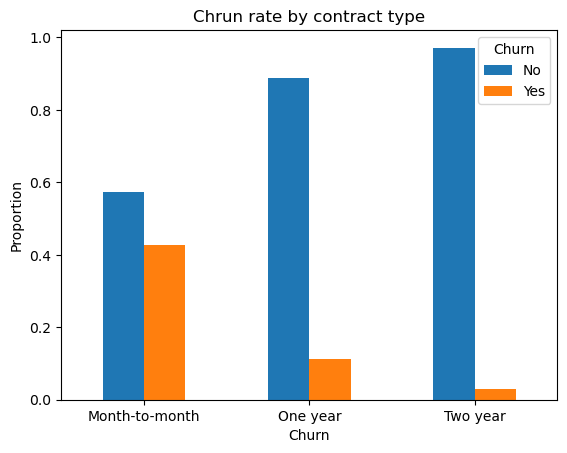

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

contract_churn=pd.crosstab(df['Contract'],df['Churn'],normalize='index')

contract_churn.plot(kind='bar')

plt.title('Chrun rate by contract type')
plt.xlabel('Churn')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [14]:
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [15]:
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                           bins=[0,12,24,48,72], 
                           labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

# Churn rate by tenure group
tenure_churn = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')
tenure_churn

Churn,No,Yes
tenure_group,,
0-1yr,0.523218,0.476782
1-2yr,0.712891,0.287109
2-4yr,0.796110,0.203890
4-6yr,0.904868,0.095132


In [16]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

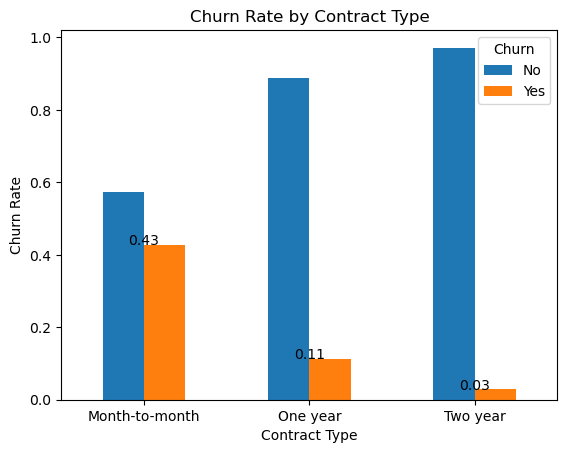

In [17]:
contract_churn.plot(kind='bar')

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)

# Add labels on bars
for i in range(len(contract_churn)):
    plt.text(i, contract_churn.iloc[i,1], 
             round(contract_churn.iloc[i,1],2), 
             ha='center')

plt.legend(title="Churn")
plt.show()

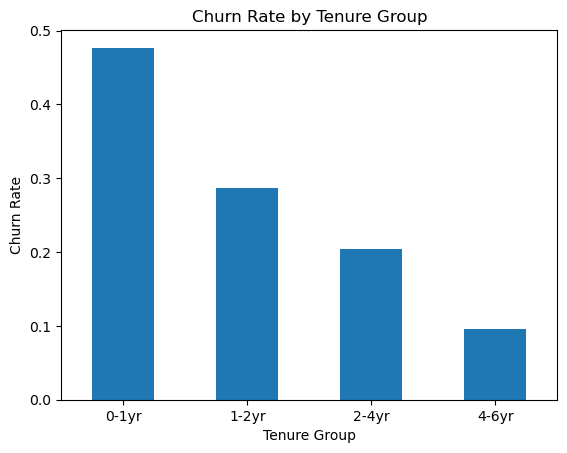

In [18]:
tenure_churn['Yes'].plot(kind='bar')
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

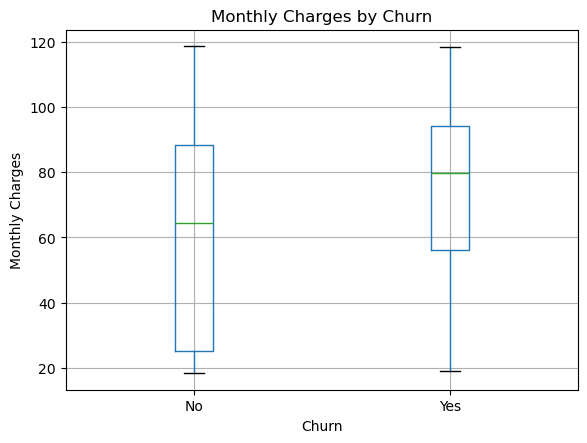

In [19]:
df.boxplot(column='MonthlyCharges', by='Churn')

plt.title("Monthly Charges by Churn")
plt.suptitle("")  # removes default extra title
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [20]:
df.to_csv("cleaned_churn.csv", index=False)

In [21]:
df.to_csv("cleaned_churn.csv", index=False)

In [22]:
df.to_csv(r"C:\Users\hemas\Downloads\cleaned_churn.csv", index=False)